# Constructed Scene Generation

Builds the two-instance scenes the spatial-language measurement requires, by
compositing rather than by filtering.

A spatial term is the sole disambiguator only when a scene holds two instances
of the same object, so that "the cup on the left" and "the cup on the right"
each name a distinct, real target. In any other scene the model can reach the
correct object by finding the only one present, and the trial measures object
detection rather than spatial language. BridgeData V2 rarely contains such a
scene: of 2239 cached frames, manual review found the qualifying set to be in
single figures, and filtering can only discard scenes, never create the ones
the measurement needs.

Each constructed scene takes a real frame holding one confident instance of the
target noun, cuts that instance from its own pixels, mirrors it, and pastes it
at a chosen position. The camera pose, lighting, and background stay real, while
the arrangement becomes known because it was chosen. The expected direction for
every trial therefore comes from recorded geometry rather than from the wording
of the instruction.

Three configurations are produced. `opposite` places one instance either side of
the start position, the classic well-posed trial. `same_side_left` and
`same_side_right` place both instances on one side: a model that grounds the
term keeps one sign for both instructions and differs only in magnitude, while a
fixed word-to-direction mapping produces opposite signs. That contrast is what
separates the two accounts, and it cannot be sampled from found data at all.

No OpenVLA load is needed. The notebook runs the open-vocabulary detector only,
so a CPU or a small GPU runtime is sufficient.

## 1. Mount Drive

In [32]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.environ['HF_HOME'] = '/content/drive/MyDrive/openvla_cache/hf'
CACHE_DIR = '/content/drive/MyDrive/openvla_cache/bridge_multiobj'
CONSTRUCTED_DIR = '/content/drive/MyDrive/openvla_cache/constructed'
assert os.path.isfile(os.path.join(CACHE_DIR, 'manifest.csv')), (
    f'No manifest at {CACHE_DIR}; run Notebook 02 cache_records first.'
)
os.makedirs(CONSTRUCTED_DIR, exist_ok=True)
print('cache       ->', CACHE_DIR)
print('constructed ->', CONSTRUCTED_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cache       -> /content/drive/MyDrive/openvla_cache/bridge_multiobj
constructed -> /content/drive/MyDrive/openvla_cache/constructed


## 2. Import the code

Clones the project code from GitHub into the runtime and imports the
construction and detection functions from there, so the code always matches the
pushed commit.

In [33]:
import sys, os, importlib, subprocess

REPO_URL = 'https://github.com/LewisTL/ECS8056.git'
BRANCH = 'master'
REPO_DIR = '/content/ECS8056'

def sync_repo():
    """Clone or hard-refresh the repository so it matches origin/BRANCH."""
    token = os.environ.get('GITHUB_TOKEN', '')
    url = REPO_URL.replace('https://', f'https://{token}@') if token else REPO_URL
    if os.path.isdir(os.path.join(REPO_DIR, '.git')):
        subprocess.run(['git', '-C', REPO_DIR, 'remote', 'set-url', 'origin', url],
                       check=True)
        subprocess.run(['git', '-C', REPO_DIR, 'fetch', '--quiet', '--depth', '1',
                        'origin', BRANCH], check=True)
        subprocess.run(['git', '-C', REPO_DIR, 'reset', '--hard', '--quiet',
                        f'origin/{BRANCH}'], check=True)
    else:
        subprocess.run(['git', 'clone', '--quiet', '--depth', '1', '--branch',
                        BRANCH, url, REPO_DIR], check=True)
    return subprocess.run(['git', '-C', REPO_DIR, 'rev-parse', '--short', 'HEAD'],
                          capture_output=True, text=True).stdout.strip()


commit = sync_repo()
module_dir = REPO_DIR
if module_dir not in sys.path:
    sys.path.insert(0, module_dir)
for _m in ('data', 'detect_duplicates', 'compose_scenes',):
    sys.modules.pop(_m, None)
importlib.invalidate_caches()

import compose_scenes
from compose_scenes import (run_construction, load_constructed_manifest,
                            select_base_scenes, locate_gripper, CONFIGURATIONS,
                            diagnose_detection, summarise_diagnosis,
                            MODE_INHERITED, MODE_SYNTHESISED,
                            SINGLE_HIGH, SINGLE_SECOND_MAX)
from data import load_manifest
print(f'imported project modules from {module_dir} @ {commit}')

imported project modules from /content/ECS8056 @ ee77e09


## 3. Eligible base frames

Two modes decide where a trial's instruction comes from, and they differ enormously
in how many frames qualify.

`inherited` uses the episode's own instruction, which must already contain a
lateral term in a referent-selection frame. Placement instructions cannot be used:
there the spatial term governs the landmark rather than the object being moved
("move the pot to the right of the spoon"), so duplicating the moved object gives
two pots while the swapped term still names a destination beside the spoon, and the
term does not choose between the two instances. That restriction leaves a very
small pool.

`synthesised` writes the instruction over the episode's manipulated object, so any
cached frame with a nameable, liftable object qualifies. Besides enlarging the pool
to the whole cache, holding the wording fixed across every trial removes
instruction form as a nuisance variable: under inherited wording, a difference
between two scenes could always be attributed to their differing phrasing rather
than to their geometry. The cost is external validity, since the instructions are
no longer verbatim from the source data, and the unmodified Bridge scenes carry
that burden instead. `instruction_source` records which mode produced each scene.

Nouns naming fixtures are refused in synthesised mode. "pick up the microwave on
the left" is unsatisfiable whatever the arrangement, and non-compliance with it
would say nothing about spatial grounding, which is the confound the constructed
set exists to remove.

The counts below are what decide which mode to use.

In [34]:
from collections import Counter

manifest_rows = load_manifest(CACHE_DIR)

inherited = select_base_scenes(manifest_rows, instruction_mode=MODE_INHERITED)
synthesised = select_base_scenes(manifest_rows, instruction_mode=MODE_SYNTHESISED)
lateral_pool = select_base_scenes(manifest_rows, categories=None,
                                  instruction_mode=MODE_INHERITED)

print(f'{len(manifest_rows)} cached scenes')
print(f'  with a lateral minimal pair    : {len(lateral_pool)}')
print(f'  inherited (referent only)      : {len(inherited)}')
print(f'  synthesised (any liftable noun): {len(synthesised)}')
print('\nlateral pool by category:', dict(Counter(
    r.get('category_manual') or r.get('category', 'other') for r in lateral_pool)))

# The synthesised nouns are written into the instruction as well as queried, so a
# bad extraction produces a nonsensical trial rather than a rejected frame. Scan
# the frequent ones for anything that is not a graspable object.
print('\nmost frequent synthesised nouns:')
for noun, count in Counter(r['target_noun'] for r in synthesised).most_common(25):
    print(f'  {count:4}  {noun}')

print('\nexample synthesised instructions:')
for row in synthesised[:5]:
    print(f"  ep{int(row['episode_index']):06d}: {row['instruction']}")

224 cached scenes
  with a lateral minimal pair    : 49
  inherited (referent only)      : 16
  synthesised (any liftable noun): 222

lateral pool by category: {'placement_relation': 33, 'referent_selection': 16}

most frequent synthesised nouns:
    19  spoon
    13  pot
    12  carrot
    11  cloth
    10  pan
     8  mushroom
     7  knife
     7  potato
     7  pepper
     7  fork
     6  eggplant
     6  bowl
     6  corn
     6  broccoli
     6  spatula
     5  brush
     4  banana
     4  strawberry
     4  towel
     4  lid
     3  colander
     3  pear
     3  detergent
     3  vertical
     2  can

example synthesised instructions:
  ep000000: pick up the can on the left
  ep000001: pick up the pot on the left
  ep000002: pick up the diagonally on the left
  ep000003: pick up the knife on the left
  ep000004: pick up the kadai on the left


## 3b. Why frames are rejected

Yield is decided almost entirely at detection, and a zero yield has two causes
that the rejection counts cannot separate. The queried noun may not name anything
in the frame, or the detector may be finding the object and scoring it below a
threshold that was set without reference to this data. The first is an extraction
fault and the second a calibration fault, and they call for opposite responses.

The diagnostic runs detection at a floor well below the working threshold and
reports the scores unfiltered. A frame whose best score sits just under
`SINGLE_HIGH` is evidence the threshold is too strict; a frame with nothing at all
above the floor is evidence the query is wrong. `recoverable_by_lowering_single_high`
counts the first kind, and the score quantiles say where a workable threshold
would sit.

The absolute score scale is a property of the detector, not of this data, which is
why the threshold is calibrated here rather than fixed in the module.

In [35]:
DIAG_MODE = MODE_SYNTHESISED   # the mode whose yield is being diagnosed
DIAG_N = 60                    # frames to probe; detection is the slow step

records = diagnose_detection(
    CACHE_DIR,
    select_base_scenes(manifest_rows, instruction_mode=DIAG_MODE),
    limit=DIAG_N,
)
summary = summarise_diagnosis(records)
print('verdicts               :', summary['by_verdict'])
print('frames with a detection:', summary['with_any_detection'], 'of',
      summary['frames'])
print('recoverable by lowering SINGLE_HIGH:',
      summary['recoverable_by_lowering_single_high'],
      f'(currently {SINGLE_HIGH})')
print('best-score quantiles   :', summary['best_score_quantiles'])

print('\nper frame:')
for record in records[:25]:
    scores = ', '.join(f'{s:.3f}' for s in record['scores']) or 'none'
    print(f"  {record['verdict']:14} {record['noun']:12} [{scores}]")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


verdicts               : {'ok': 13, 'multi_instance': 20, 'weak_instance': 26, 'no_instance': 1}
frames with a detection: 59 of 60
recoverable by lowering SINGLE_HIGH: 26 (currently 0.25)
best-score quantiles   : {'p10': 0.0606, 'p25': 0.1552, 'p50': 0.2762, 'p75': 0.4344, 'p90': 0.5103}

per frame:
  ok             can          [0.368, 0.125, 0.093]
  multi_instance pot          [0.494, 0.273, 0.124]
  weak_instance  diagonally   [0.052, 0.049, 0.048]
  multi_instance knife        [0.385, 0.256, 0.191]
  ok             kadai        [0.255, 0.127, 0.044]
  weak_instance  banana       [0.196, 0.051]
  multi_instance napkin       [0.258, 0.154, 0.088]
  multi_instance pot          [0.576, 0.213, 0.095]
  weak_instance  eggplant     [0.167, 0.137, 0.082]
  weak_instance  wedge        [0.080, 0.069, 0.051]
  weak_instance  eggplant     [0.105, 0.066, 0.063]
  weak_instance  outside      [0.055, 0.039, 0.039]
  multi_instance cloth        [0.460, 0.164, 0.110]
  weak_instance  strawberry   

The scores above are only trustworthy if the boxes are on the objects. A confident
detection of the wrong region would pass the gate and then be cut, so the panels
below draw the top box for each frame. Read them for whether the box encloses the
named object, not for whether the score is high.

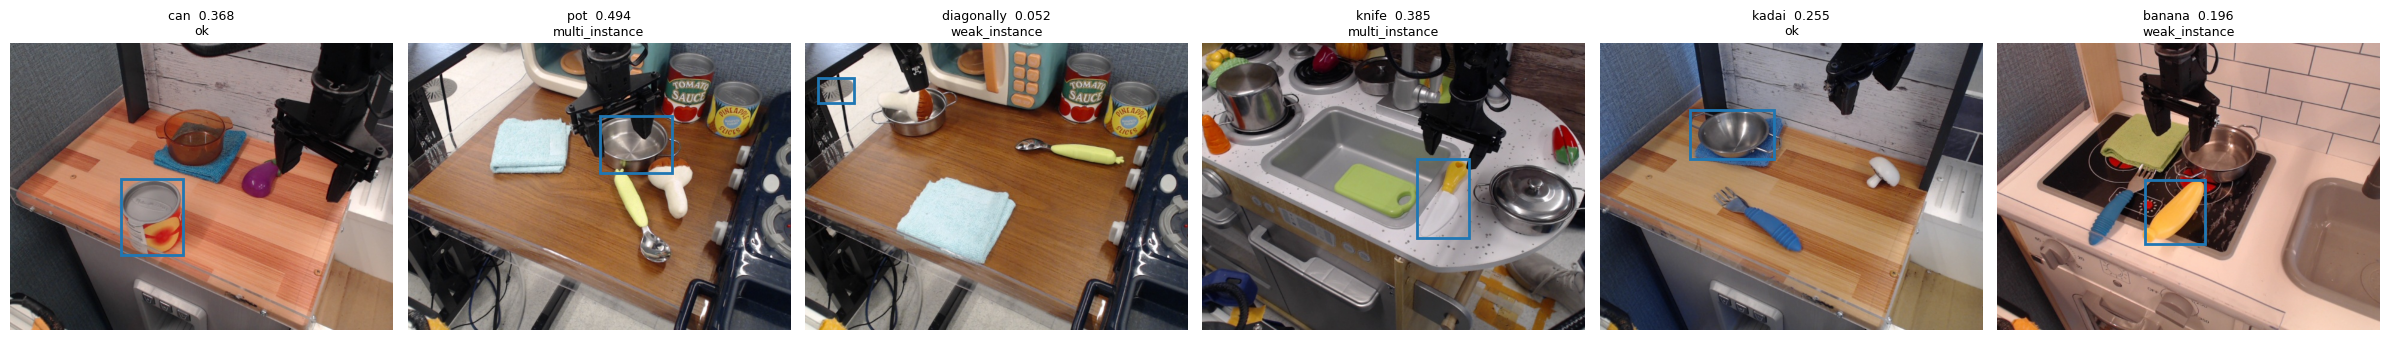

In [36]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

shown = [r for r in records if r['boxes']][:6]
if shown:
    fig, axes = plt.subplots(1, len(shown), figsize=(4 * len(shown), 4.4))
    axes = [axes] if len(shown) == 1 else list(axes)
    for ax, record in zip(axes, shown):
        ax.imshow(Image.open(os.path.join(CACHE_DIR, record['image_path'])))
        x0, y0, x1, y1 = record['boxes'][0]
        ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False,
                               edgecolor='tab:blue', linewidth=2))
        ax.set_title(f"{record['noun']}  {record['scores'][0]:.3f}"
                     f"\n{record['verdict']}", fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('No detections at all. The queried nouns, not the thresholds, are the '
          'problem: check the noun list printed above against the frames.')

## 4. Build the constructed set

For each eligible frame the target noun is detected, and frames holding anything
other than exactly one confident instance are skipped: a second instance means
the scene is already a two-instance trial, and no instance means there is nothing
to duplicate. Every configuration the frame can support is then built.

A configuration is skipped rather than approximated when it cannot be realised,
for example when the duplicate would leave the frame or land on the wrong side
of the start position. Every constructed scene is therefore one where the
intended arrangement was actually achieved, so the recorded geometry can be
trusted without further inspection. The rejection counts are printed so the
yield is visible rather than silent.

The duplicate is cut along the object's own outline, obtained by prompting a
segmentation model with the detected box. Cutting along the bounding box instead
transfers the table, the shadow, and any neighbouring object that falls inside
the rectangle, which is why a box cutout reads as a pasted rectangle rather than
as a second object. Scenes fall back to a box cutout when segmentation is
unavailable, and `by_cutout` reports how many did.

`SINGLE_HIGH` and `SINGLE_SECOND_MAX` are set from the diagnostic above rather
than left at their defaults. Raising `SINGLE_HIGH` buys trustworthy boxes at the
cost of frames; lowering it does the reverse. The gate that applies them is shared
with the diagnostic, so what was reported there is what is built here.

Set `LIMIT` to a small number for a trial run before building the full set.

In [37]:
INSTRUCTION_MODE = MODE_SYNTHESISED  # or MODE_INHERITED for verbatim wording
LIMIT = None            # e.g. 25 for a trial run
DETECT_GRIPPER = True   # fall back to the image centre when detection fails
SEGMENT = True          # cut along the object outline rather than its box

# Calibrated against the quantiles reported in section 3b.
GATE_SINGLE_HIGH = SINGLE_HIGH
GATE_SINGLE_SECOND_MAX = SINGLE_SECOND_MAX

summary = run_construction(
    CACHE_DIR, CONSTRUCTED_DIR,
    manifest_rows=manifest_rows,
    limit=LIMIT,
    detect_gripper=DETECT_GRIPPER,
    segment=SEGMENT,
    instruction_mode=INSTRUCTION_MODE,
    single_high=GATE_SINGLE_HIGH,
    single_second_max=GATE_SINGLE_SECOND_MAX,
)
summary

[write_constructed_manifest] wrote 29 scenes -> /content/drive/MyDrive/openvla_cache/constructed/constructed_manifest.csv
[run_construction] 222 candidate frames -> 29 constructed scenes {'same_side_left': 11, 'opposite': 10, 'same_side_right': 8}
[run_construction] cutouts: {'mask': 29}
[run_construction] rejected: {'no_instance': 36, 'weak_instance': 54, 'multi_instance': 83, 'no_surface': 0, 'no_placement': 23, 'missing_frame': 0}


{'candidates': 222,
 'constructed': 29,
 'by_configuration': {'same_side_left': 11,
  'opposite': 10,
  'same_side_right': 8},
 'by_cutout': {'mask': 29},
 'rejected': {'no_instance': 36,
  'weak_instance': 54,
  'multi_instance': 83,
  'no_surface': 0,
  'no_placement': 23,
  'missing_frame': 0}}

## 5. Inspect the recorded geometry

The measurement reads direction from the manifest, not from the picture, so the
manifest and the picture must agree. Each panel draws the recorded boxes onto the
constructed frame: the source instance, the pasted duplicate, and the start
position.

The boxes are drawn at their recorded coordinates rather than as markers at a
nominal height, because that is what makes a fault visible. A box that sits above
or beside the object it names means the cut was taken from the wrong pixels, and
the duplicate will then be a patch of background. Such a scene must be rebuilt,
not merely excluded, since the same fault affects every scene from that frame.

`cutout` reports whether the duplicate was cut along the object's outline
(`mask`) or along its bounding box (`box`). A box cutout carries the table and
any neighbouring object inside the rectangle, so it reads as a pasted rectangle
rather than as a second object.

29 constructed scenes in the manifest


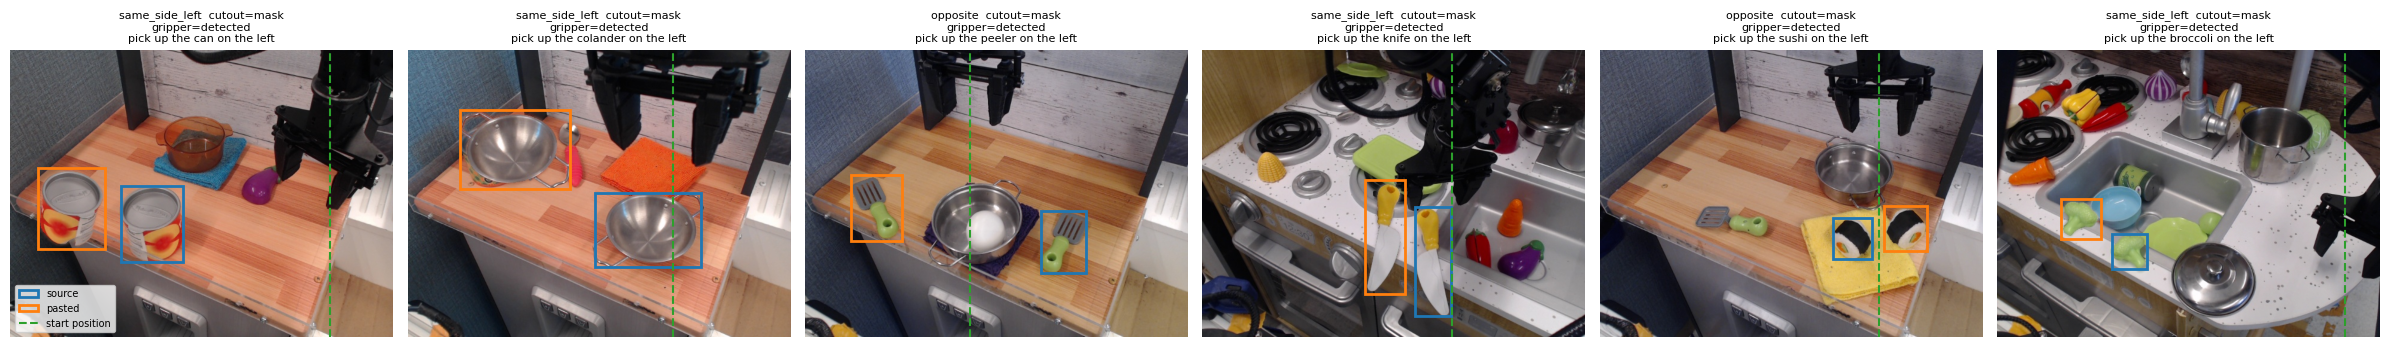

In [38]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

scenes = load_constructed_manifest(CONSTRUCTED_DIR)
print(f'{len(scenes)} constructed scenes in the manifest')


def draw_box(ax, spec, colour, label):
    """Draw a recorded 'x0,y0,x1,y1' box at its own coordinates."""
    if not spec:
        return
    x0, y0, x1, y1 = (float(v) for v in spec.split(','))
    ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False,
                           edgecolor=colour, linewidth=2, label=label))


N_SHOW = 6
sample = scenes[:N_SHOW]
if sample:
    fig, axes = plt.subplots(1, len(sample), figsize=(4 * len(sample), 4.6))
    axes = [axes] if len(sample) == 1 else list(axes)
    for ax, scene in zip(axes, sample):
        image = Image.open(os.path.join(CONSTRUCTED_DIR, scene['image_path']))
        ax.imshow(image)
        draw_box(ax, scene['source_box'], 'tab:blue', 'source')
        draw_box(ax, scene['paste_box'], 'tab:orange', 'pasted')
        ax.axvline(float(scene['x_gripper']), color='tab:green', linestyle='--',
                   linewidth=1.5, label='start position')
        ax.set_title(f"{scene['configuration']}  cutout={scene['cutout_mode']}"
                     f"\ngripper={scene['gripper_source']}"
                     f"\n{scene['instr_a']}", fontsize=8)
        ax.axis('off')
    axes[0].legend(loc='lower left', fontsize=7)
    plt.tight_layout()
    plt.show()

## 6. Yield and balance

The analysis compares configurations against each other, so a badly unbalanced
set would leave the decisive same-side comparison underpowered even when the
total looks healthy. The counts below are what determine whether the constructed
set can carry the primary analysis.

`gripper_source` records how the start position was obtained for each scene.
A high fallback rate weakens the same-side configurations specifically, because
those are defined relative to that position, and it should be reported alongside
the result.

In [39]:
import pandas as pd

manifest = pd.DataFrame(scenes)
if len(manifest):
    for col in ('separation_px', 'offset_a_px', 'offset_b_px', 'source_score'):
        manifest[col] = manifest[col].astype(float)

    print('scenes per configuration:')
    print(manifest['configuration'].value_counts().to_string())
    print('\nspatial term:', dict(manifest['spatial_term'].value_counts()))
    print('gripper localisation:', dict(manifest['gripper_source'].value_counts()))
    print(f"\nbase frames used: {manifest['base_scene_id'].nunique()}")
    print(f"distinct target nouns: {manifest['noun'].nunique()}")
    print('\nseparation between instances (px):')
    print(manifest.groupby('configuration')['separation_px'].describe()[
        ['count', 'mean', 'min', 'max']].to_string())

    # A same-side scene must have both targets on one side of the start
    # position, and an opposite scene must straddle it. Verified against the
    # recorded numbers rather than assumed from the label.
    same_side = (manifest['offset_a_px'] * manifest['offset_b_px'] > 0)
    expected = manifest['configuration'] != 'opposite'
    print(f'\ngeometry consistent with the configuration label: '
          f'{int((same_side == expected).sum())}/{len(manifest)}')

scenes per configuration:
configuration
same_side_left     11
opposite           10
same_side_right     8

spatial term: {'left': np.int64(29)}
gripper localisation: {'detected': np.int64(21), 'image_center': np.int64(8)}

base frames used: 26
distinct target nouns: 20

separation between instances (px):
                 count        mean         min         max
configuration                                             
opposite          10.0  192.217131   65.235809  334.211807
same_side_left    11.0  125.290013   79.144006  221.826929
same_side_right    8.0  150.128384  102.932098  239.188916

geometry consistent with the configuration label: 29/29


## 7. Validation sample

The measurement reads direction from the recorded geometry, so that geometry is
the central assumption of the constructed set, and it rests on an open-vocabulary
detector never evaluated on this data. A hand-labelled sample gives it a
reportable agreement number instead of an assumption.

The sample is drawn at random and stratified by configuration, never chosen. A
sample picked by eye would be selected on the same appearance the labelling then
judges, and its agreement would measure nothing. Stratifying keeps the same-side
arrangements represented, since they are fewer and carry the decisive comparison.

The 108 feasibility labels already collected in Notebook 02b form the feasibility
half of the validation and are reported alongside these; they are not recollected
here.

In [40]:
from compose_scenes import (draw_validation_sample, write_validation_sample,
                            load_validation_sample, validation_agreement)

SAMPLE_N = 50
SAMPLE_SEED = 0

sample = draw_validation_sample(scenes, n=SAMPLE_N, seed=SAMPLE_SEED)
write_validation_sample(sample, CONSTRUCTED_DIR)
print(f'{len(sample)} scenes drawn for labelling')
print('by configuration:', dict(Counter(r['configuration'] for r in sample)))
print('by cutout:', dict(Counter(r['auto_cutout_mode'] for r in sample)))

[write_validation_sample] 29 scenes -> /content/drive/MyDrive/openvla_cache/constructed/validation_sample.csv
29 scenes drawn for labelling
by configuration: {'opposite': 10, 'same_side_left': 11, 'same_side_right': 8}
by cutout: {'mask': 29}


### Annotator

Each panel shows one constructed scene with no markers, so the arrangement is
judged from the image rather than read off the pipeline's own answer. Record
what the image shows: how the two instances sit relative to the robot's start
position, whether two instances of the named object are visible at all, whether
the start position is where the arm actually is, and whether the duplicate reads
as a real object rather than a pasted rectangle.

Each save writes the whole sample file and advances, so a session can be
interrupted and resumed.

In [41]:
import ipywidgets as widgets
from IPython.display import display, clear_output

rows = load_validation_sample(CONSTRUCTED_DIR)
by_id = {s['construct_id']: s for s in scenes}
queue = [r for r in rows if not r['human_configuration']]
print(f'{len(queue)} unlabelled of {len(rows)}')

state = {'i': 0}
out = widgets.Output()

configuration = widgets.ToggleButtons(
    options=['opposite', 'same_side_left', 'same_side_right', 'unclear'],
    description='Arrangement:', style={'description_width': 'initial'})
two_instances = widgets.ToggleButtons(
    options=['yes', 'no'], description='Two instances visible:',
    style={'description_width': 'initial'})
gripper_ok = widgets.ToggleButtons(
    options=['yes', 'no'], description='Start position on the arm:',
    style={'description_width': 'initial'})
paste_ok = widgets.ToggleButtons(
    options=['yes', 'no'], description='Duplicate looks real:',
    style={'description_width': 'initial'})
notes = widgets.Text(description='Notes:', layout=widgets.Layout(width='60%'))
save_button = widgets.Button(description='Save and next', button_style='primary')
skip_button = widgets.Button(description='Skip')


def show():
    with out:
        clear_output(wait=True)
        if state['i'] >= len(queue):
            print('queue complete')
            return
        row = queue[state['i']]
        scene = by_id.get(row['construct_id'])
        print(f"[{state['i'] + 1}/{len(queue)}] {row['construct_id']}")
        print('instruction A:', row['instr_a'])
        if scene is None:
            print('image missing from the manifest')
            return
        image = Image.open(os.path.join(CONSTRUCTED_DIR, scene['image_path']))
        fig, ax = plt.subplots(figsize=(5.5, 5.5))
        ax.imshow(image)
        ax.axis('off')
        plt.show()


def save(_):
    row = queue[state['i']]
    row['human_configuration'] = configuration.value
    row['human_two_instances'] = two_instances.value
    row['human_gripper_ok'] = gripper_ok.value
    row['human_paste_plausible'] = paste_ok.value
    row['notes'] = notes.value
    write_validation_sample(rows, CONSTRUCTED_DIR)
    notes.value = ''
    state['i'] += 1
    show()


def skip(_):
    state['i'] += 1
    show()


save_button.on_click(save)
skip_button.on_click(skip)
display(widgets.VBox([out, configuration, two_instances, gripper_ok, paste_ok,
                      notes, widgets.HBox([save_button, skip_button])]))
show()

29 unlabelled of 29


### Agreement

The number reported with the constructed set. Configuration agreement is what
the geometry claim rests on. Gripper agreement bears mainly on the same-side
configurations, since those are defined relative to the start position, so a low
value weakens the decisive comparison specifically rather than the whole set.

A low paste-plausibility rate points the same way as a failed manipulation check
in Notebook 04. It is reported per cutout mode, because an outline cutout and a
bounding-box cutout are different stimuli and the box is expected to look worse:
pooling them would average away the distinction that decides whether any box
fallbacks are usable. If outline cutouts also read poorly, the remaining levers
are matching the duplicate's scale and vertical position to the table perspective
and harmonising its colour to the local lighting.

In [43]:
agreement = validation_agreement(load_validation_sample(CONSTRUCTED_DIR))
print(f"labelled {agreement['labelled']} of {agreement['drawn']} drawn")
print(f"configuration agreement : {agreement['configuration_agreement']:.1%}")
print(f"two instances visible   : {agreement['two_instances_rate']:.1%}")
print(f"start position correct  : {agreement['gripper_agreement']:.1%}")
print(f"duplicate looks real    : {agreement['paste_plausible_rate']:.1%}")
print('\nby recorded configuration:')
for name, entry in sorted(agreement['by_configuration'].items()):
    print(f"  {name:16} n={entry['n']:3}  agreement={entry['agreement']:.1%}")
print('\nduplicate looks real, by cutout:')
for name, entry in sorted(agreement['by_cutout'].items()):
    print(f"  {name:6} n={entry['n']:3}  "
          f"plausible={entry['paste_plausible_rate']:.1%}")

# The feasibility half of the validation, already collected in Notebook 02b.
reviewed = [r for r in manifest_rows
            if r.get('feasible_both', 'unreviewed') != 'unreviewed']
print(f'\nfeasibility labels carried over from Notebook 02b: {len(reviewed)}')

labelled 29 of 29 drawn
configuration agreement : 93.1%
two instances visible   : 100.0%
start position correct  : 100.0%
duplicate looks real    : 69.0%

by recorded configuration:
  opposite         n= 10  agreement=100.0%
  same_side_left   n= 11  agreement=81.8%
  same_side_right  n=  8  agreement=100.0%

duplicate looks real, by cutout:
  mask   n= 29  plausible=69.0%

feasibility labels carried over from Notebook 02b: 0
